# Optuna's logs preprocessing

In [21]:
from pathlib import Path
import optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
DB_PATH = Path("outputs_patchcore/pdt_public_patchcore_hpo_logs.db")
STORAGE = f"sqlite:///{DB_PATH.as_posix()}"
STUDY_NAME = "pdt_public_patchcore_hpo_logs_v1.0.1"

In [29]:
study = optuna.load_study(study_name=STUDY_NAME, storage=STORAGE)
print("loaded:", study.study_name, "| trials:", len(study.trials), "| best:", study.best_value)

df = study.trials_dataframe(attrs=("number","value","state","params","user_attrs"))
df = df[df["state"] == "COMPLETE"].copy()
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df = df.dropna(subset=["value"])
df.head()


loaded: pdt_public_patchcore_hpo_logs_v1.0.1 | trials: 3000 | best: 0.907563025210084


,number,value,state,params_backbone,params_batch_size,params_center_crop_key,params_coreset_sampling_ratio,params_image_size_key,params_layers_key,params_max_patches_per_image,...,user_attrs_auroc_val,user_attrs_f1_val_at_budget,user_attrs_memory_bank_size,user_attrs_oom,user_attrs_precision_val_at_budget,user_attrs_recall_val_at_budget,user_attrs_runtime_sec,user_attrs_soft_train_fraction_q01,user_attrs_threshold_val_budget,user_attrs_train_good_used
0,0,0.695060,COMPLETE,wide_resnet50_2,8,0.875,0.055,256,l3,1024,...,0.858748,0.695060,24459.0,False,0.710801,0.680000,27.666281,0.50,29.402639,2269.0
1,1,0.090909,COMPLETE,resnet34,8,0.875,0.099,320,l2,128,...,0.374186,0.090909,35076.0,False,0.187500,0.060000,14.286474,0.61,3.066057,2768.0
2,2,0.578411,COMPLETE,resnet34,8,0.875,0.003,256,l2_l3,512,...,0.800494,0.578411,4600.0,False,0.743455,0.473333,40.138176,0.66,7.571294,2995.0
3,3,0.095665,COMPLETE,wide_resnet50_2,8,none,0.093,320,l2,512,...,0.125814,0.095665,73471.0,False,0.086721,0.106667,56.177743,0.34,34.505644,1543.0
4,4,0.000000,COMPLETE,resnet50,8,none,0.045,256,l2,128,...,0.034874,0.000000,13069.0,False,0.000000,0.000000,22.857071,0.50,7.946904,2269.0


In [30]:
s = df["value"]
print("n complete:", len(df))
print(s.describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99]))


n complete: 2999
count    2999.000000
mean        0.507049
std         0.338529
min         0.000000
1%          0.005659
5%          0.031250
10%         0.058916
25%         0.129114
50%         0.568075
75%         0.833052
90%         0.895238
95%         0.900000
99%         0.904202
max         0.907563
Name: value, dtype: float64


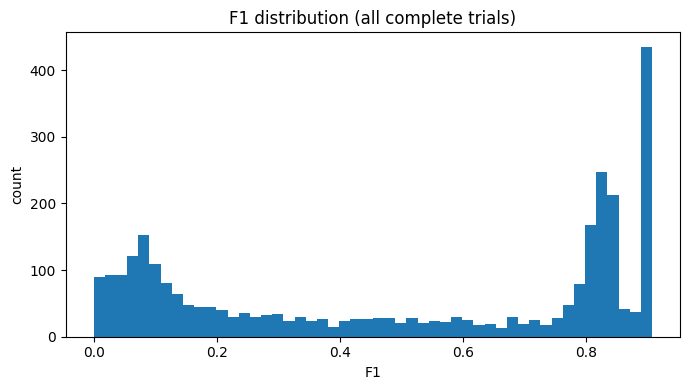

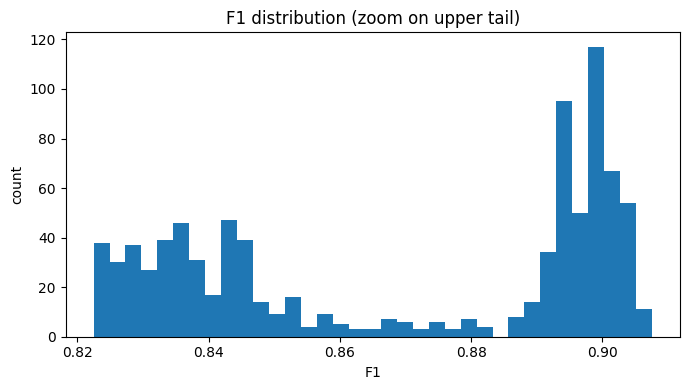

In [31]:
s = df["value"].to_numpy()

plt.figure(figsize=(7,4))
plt.hist(s, bins=50)
plt.title("F1 distribution (all complete trials)")
plt.xlabel("F1"); plt.ylabel("count")
plt.tight_layout(); plt.show()

plt.figure(figsize=(7,4))
plt.hist(s[s >= max(0.0, np.quantile(s, 0.7))], bins=35)
plt.title("F1 distribution (zoom on upper tail)")
plt.xlabel("F1"); plt.ylabel("count")
plt.tight_layout(); plt.show()


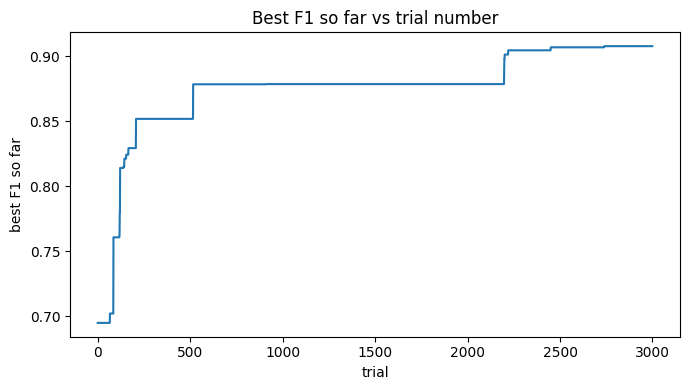

In [32]:
best_so_far = df.sort_values("number")["value"].cummax()

plt.figure(figsize=(7,4))
plt.plot(df.sort_values("number")["number"], best_so_far)
plt.title("Best F1 so far vs trial number")
plt.xlabel("trial"); plt.ylabel("best F1 so far")
plt.tight_layout(); plt.show()


/tmp/ipykernel_426/922683307.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cats, showfliers=False)


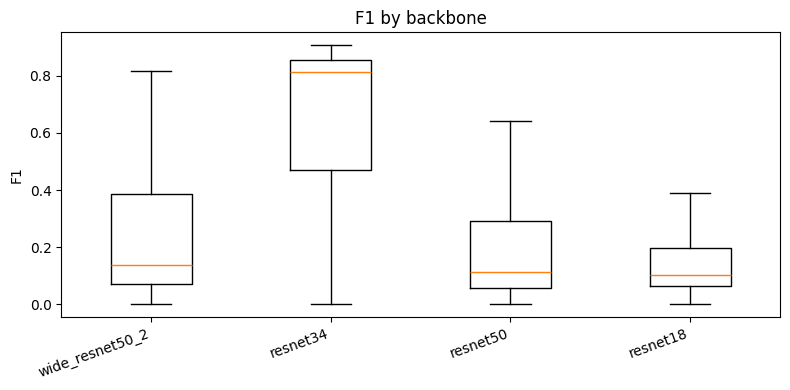

/tmp/ipykernel_426/922683307.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cats, showfliers=False)


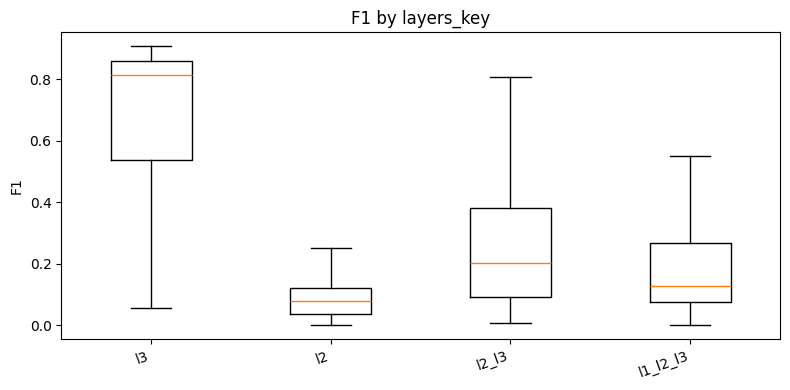

/tmp/ipykernel_426/922683307.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cats, showfliers=False)


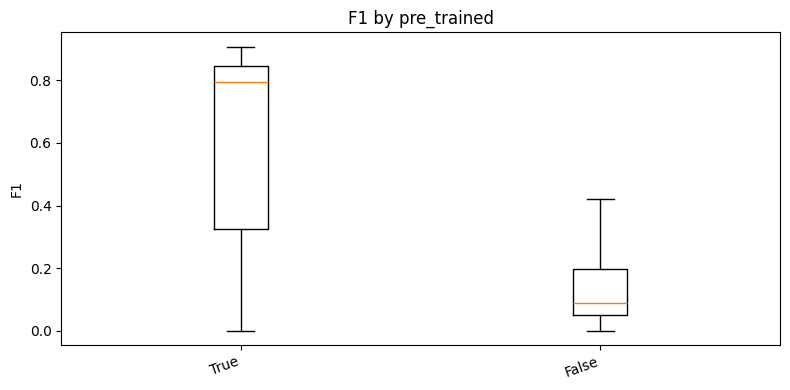

/tmp/ipykernel_426/922683307.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cats, showfliers=False)


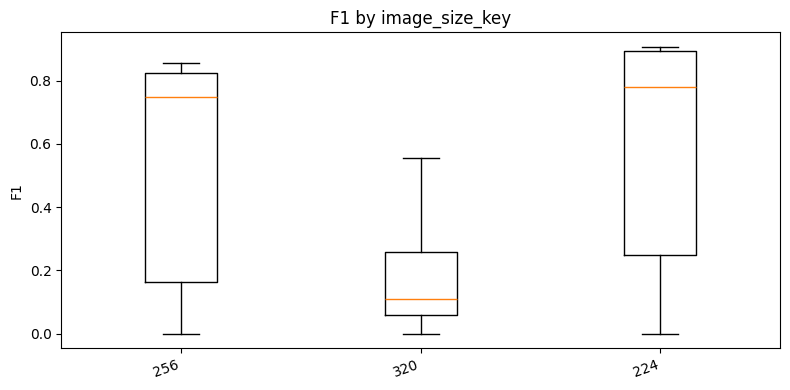

/tmp/ipykernel_426/922683307.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cats, showfliers=False)


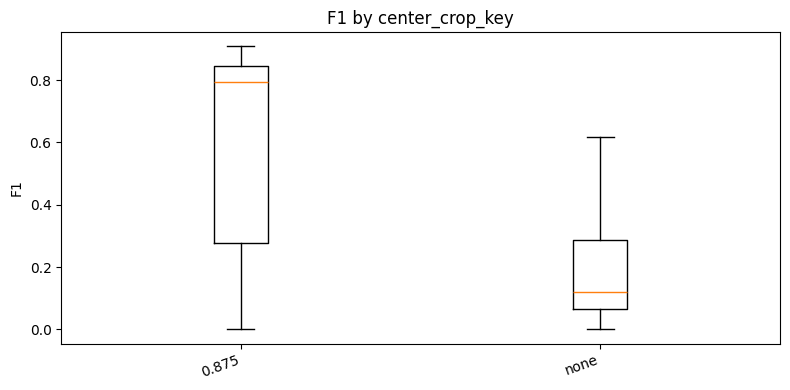

/tmp/ipykernel_426/922683307.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cats, showfliers=False)


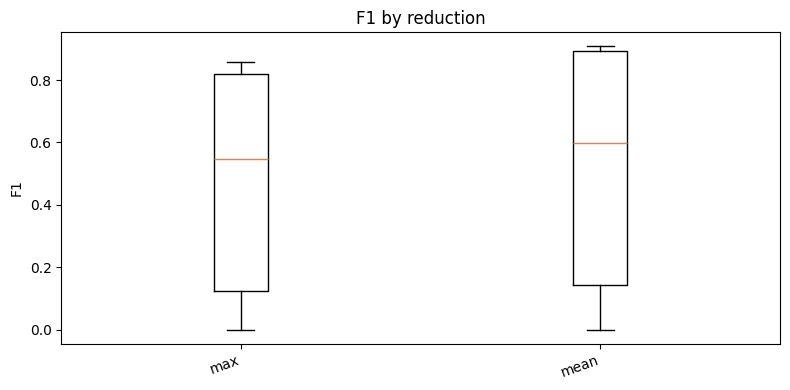

/tmp/ipykernel_426/922683307.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cats, showfliers=False)


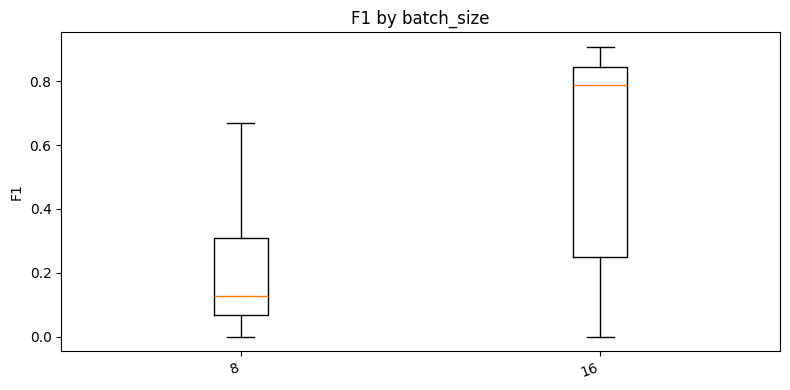

/tmp/ipykernel_426/922683307.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cats, showfliers=False)


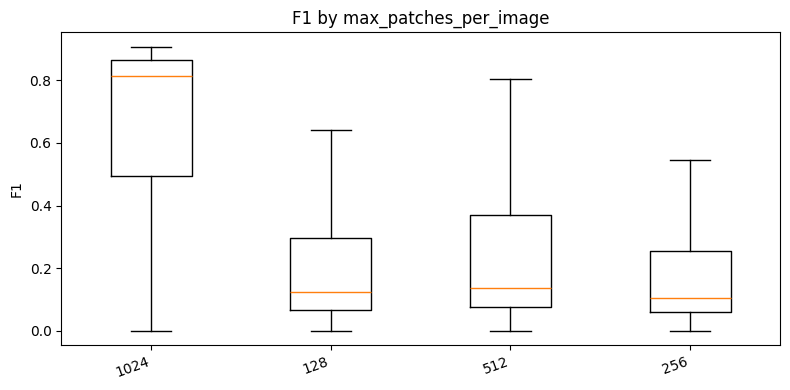

In [34]:
# pick a few params you care about (edit this list freely)
params_to_plot = [
    "params_backbone",
    "params_layers_key",
    "params_pre_trained",
    "params_image_size_key",
    "params_center_crop_key",
    "params_reduction",
    "params_batch_size",
    "params_max_patches_per_image",
]

for col in params_to_plot:
    if col not in df.columns:
        continue
    g = df[[col, "value"]].dropna()
    # keep plot readable (avoid very large category counts)
    if g[col].nunique() > 15:
        continue

    cats = list(g[col].astype(str).unique())
    data = [g.loc[g[col].astype(str)==c, "value"].values for c in cats]

    plt.figure(figsize=(8,4))
    plt.boxplot(data, labels=cats, showfliers=False)
    plt.title(f"F1 by {col.replace('params_','')}")
    plt.ylabel("F1")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


In [37]:
best_row = df.loc[df["value"].idxmax()].copy()
print("best trial:", int(best_row["number"]), "| F1:", float(best_row["value"]))

best_params = {k.replace("params_", ""): best_row[k] for k in df.columns if k.startswith("params_")}
best_attrs  = {k.replace("user_attrs_", ""): best_row[k] for k in df.columns if k.startswith("user_attrs_")}

print("\nBest params:")
for k,v in best_params.items():
    print(f"  {k}: {v}")


best trial: 2739 | F1: 0.907563025210084

Best params:
  backbone: resnet34
  batch_size: 16
  center_crop_key: 0.875
  coreset_sampling_ratio: 0.091
  image_size_key: 224
  layers_key: l3
  max_patches_per_image: 1024
  num_neighbors: 1
  pre_trained: True
  reduction: mean
  soft_corruption_level: none
  soft_review_budget: 0.34
  soft_train_fraction: 0.9000000000000001


In [44]:
df.describe()

,number,value,params_batch_size,params_coreset_sampling_ratio,params_max_patches_per_image,params_num_neighbors,params_soft_review_budget,params_soft_train_fraction,user_attrs_auroc_val,user_attrs_f1_val_at_budget,user_attrs_memory_bank_size,user_attrs_precision_val_at_budget,user_attrs_recall_val_at_budget,user_attrs_runtime_sec,user_attrs_soft_train_fraction_q01,user_attrs_threshold_val_budget,user_attrs_train_good_used
count,2999.000000,2999.000000,2999.000000,2999.000000,2999.000000,2999.000000,2999.000000,2999.000000,2999.000000,2999.000000,2999.000000,2999.000000,2999.000000,2999.000000,2999.000000,2999.000000,2999.000000
mean,1499.918306,0.507049,14.271424,0.074850,771.883961,8.327442,0.282431,0.765535,0.685087,0.507049,63278.062688,0.597653,0.494502,49.956584,0.765535,17.484254,3473.989663
std,866.011048,0.338529,3.293061,0.030472,358.262120,9.232965,0.132092,0.222859,0.350799,0.338529,44803.548752,0.340465,0.360295,69.854831,0.222859,30.214772,1011.327704
min,0.000000,0.000000,8.000000,0.001000,128.000000,1.000000,0.005000,0.200000,0.028548,0.000000,261.000000,0.000000,0.000000,8.199750,0.200000,1.733486,908.000000
25%,750.500000,0.129114,16.000000,0.055000,512.000000,1.000000,0.175000,0.650000,0.302681,0.129114,35321.000000,0.208371,0.110000,20.149543,0.650000,2.381320,2950.000000
50%,1500.000000,0.568075,16.000000,0.093000,1024.000000,3.000000,0.340000,0.860000,0.937061,0.568075,64531.000000,0.774799,0.476667,38.041390,0.860000,3.963025,3903.000000
75%,2249.500000,0.833052,16.000000,0.097000,1024.000000,15.000000,0.375000,0.930000,0.969433,0.833052,81105.000000,0.880392,0.876667,56.710555,0.930000,13.693652,4220.000000
max,2999.000000,0.907563,16.000000,0.101000,1024.000000,30.000000,0.500000,1.000000,0.975173,0.907563,446257.000000,1.000000,0.980000,1266.177268,1.000000,280.466060,4538.000000


In [46]:
df.head().T

,0,1,2,3,4
number,0,1,2,3,4
value,0.69506,0.090909,0.578411,0.095665,0.0
state,COMPLETE,COMPLETE,COMPLETE,COMPLETE,COMPLETE
params_backbone,wide_resnet50_2,resnet34,resnet34,wide_resnet50_2,resnet50
params_batch_size,8,8,8,8,8
params_center_crop_key,0.875,0.875,0.875,none,none
params_coreset_sampling_ratio,0.055,0.099,0.003,0.093,0.045
params_image_size_key,256,320,256,320,256
params_layers_key,l3,l2,l2_l3,l2,l2
params_max_patches_per_image,1024,128,512,512,128


In [47]:
df.count()

number                                2999
value                                 2999
state                                 2999
params_backbone                       2999
params_batch_size                     2999
params_center_crop_key                2999
params_coreset_sampling_ratio         2999
params_image_size_key                 2999
params_layers_key                     2999
params_max_patches_per_image          2999
params_num_neighbors                  2999
params_pre_trained                    2999
params_reduction                      2999
params_soft_corruption_level          2999
params_soft_review_budget             2999
params_soft_train_fraction            2999
user_attrs_auroc_val                  2999
user_attrs_f1_val_at_budget           2999
user_attrs_memory_bank_size           2999
user_attrs_oom                        2999
user_attrs_precision_val_at_budget    2999
user_attrs_recall_val_at_budget       2999
user_attrs_runtime_sec                2999
user_attrs_

In [48]:
cols_to_drop = [
    "user_attrs_soft_train_fraction_q01",
    "user_attrs_f1_val_at_budget",
    "number",
    "state",
]

df = df.drop(columns=cols_to_drop, errors="ignore")


In [51]:
df["params_soft_train_fraction"] = df["params_soft_train_fraction"].round(2)
df["params_coreset_sampling_ratio"] = df["params_coreset_sampling_ratio"].round(3)
df["params_soft_review_budget"] = df["params_soft_review_budget"].round(3)


In [56]:
df.head().T

,0,1,2,3,4
value,0.69506,0.090909,0.578411,0.095665,0.0
params_backbone,wide_resnet50_2,resnet34,resnet34,wide_resnet50_2,resnet50
params_batch_size,8,8,8,8,8
params_center_crop_key,0.875,0.875,0.875,none,none
params_coreset_sampling_ratio,0.055,0.099,0.003,0.093,0.045
params_image_size_key,256,320,256,320,256
params_layers_key,l3,l2,l2_l3,l2,l2
params_max_patches_per_image,1024,128,512,512,128
params_num_neighbors,25,26,25,25,16
params_pre_trained,True,True,True,True,False


In [58]:
# -----------------------------
# 1) Define target + features
# -----------------------------
TARGET = "value"

FEATURES = [
    "params_backbone",
    "params_batch_size",
    "params_center_crop_key",
    "params_coreset_sampling_ratio",
    "params_image_size_key",
    "params_layers_key",
    "params_max_patches_per_image",
    "params_num_neighbors",
    "params_pre_trained",
    "params_reduction",
    "params_soft_corruption_level",
    "params_soft_review_budget",
    "params_soft_train_fraction",
]

keep_cols = [TARGET] + FEATURES


Saved: patchcore_surrogate_dataset_xgb.csv
Shape: (2999, 14)


,value,params_backbone,params_batch_size,params_center_crop_key,params_coreset_sampling_ratio,params_image_size_key,params_layers_key,params_max_patches_per_image,params_num_neighbors,params_pre_trained,params_reduction,params_soft_corruption_level,params_soft_review_budget,params_soft_train_fraction
0,0.695060,wide_resnet50_2,8,0.875,0.055,256,l3,1024,25,True,max,none,0.330,0.50
1,0.090909,resnet34,8,0.875,0.099,320,l2,128,26,True,mean,none,0.110,0.61
2,0.578411,resnet34,8,0.875,0.003,256,l2_l3,512,25,True,max,strong,0.220,0.66
3,0.095665,wide_resnet50_2,8,none,0.093,320,l2,512,25,True,max,strong,0.425,0.34
4,0.000000,resnet50,8,none,0.045,256,l2,128,16,False,mean,mild,0.060,0.50


In [ ]:
# -----------------------------
# 2) Subset + basic cleaning
# -----------------------------
df_export = df.loc[:, keep_cols].copy()

# Drop rows with missing values in any kept column
df_export = df_export.dropna(subset=keep_cols)


In [ ]:
# -----------------------------
# 3) Enforce stable dtypes
# -----------------------------
# Treat these as categorical strings (important for one-hot later)
cat_as_str = [
    "params_backbone",
    "params_center_crop_key",
    "params_image_size_key",           # looks numeric but is a key -> treat as categorical
    "params_layers_key",
    "params_pre_trained",              # bool -> stringify for stable one-hot
    "params_reduction",
    "params_soft_corruption_level",
    "params_batch_size",               # {8,16} but categorical choice
    "params_max_patches_per_image",    # {128,256,512,1024} categorical choice
]
for c in cat_as_str:
    df_export[c] = df_export[c].astype(str)

# Ensure numeric columns are numeric
num_cols = ["params_coreset_sampling_ratio", "params_num_neighbors", "params_soft_review_budget", "params_soft_train_fraction", TARGET]
for c in num_cols:
    df_export[c] = pd.to_numeric(df_export[c], errors="coerce")

df_export = df_export.dropna(subset=num_cols)

In [ ]:
# -----------------------------
# 5) Export to CSV
# -----------------------------
out_path = "surrogate_ready_dataset/patchcore_surrogate_dataset_xgb.csv"
df_export.to_csv(out_path, index=False)

print("Saved:", out_path)
print("Shape:", df_export.shape)
df_export.head()